# S2 数组计算与可视化: Questions

Q1: 灰度化

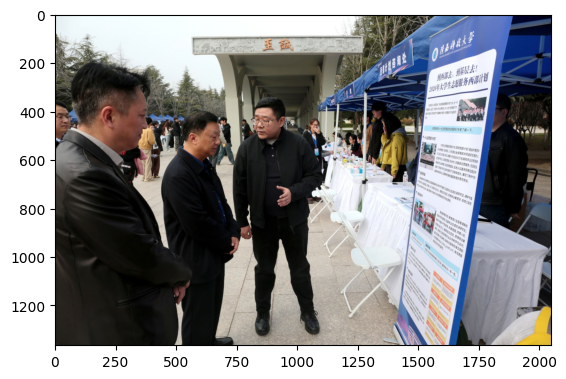

In [1]:
import matplotlib.pyplot as plt
img = plt.imread('51A824FB05990827233BE1BA706_59A83903_5999D.jpg')
plt.imshow(img)
plt.show()

In [2]:
h, w, c = img.shape
img_list = img.tolist()

In [3]:
%%timeit
gray = [[0]*w for _ in range(h)]
for i in range(h):
    for j in range(w):
        r = img_list[i][j][2]
        g = img_list[i][j][1]
        b = img_list[i][j][0]
        gray[i][j] = 0.299*r + 0.587*g + 0.114*b

473 ms ± 8.76 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [4]:
%%timeit
gray = 0.299*img[:,:,2] + 0.587*img[:,:,1] + 0.114*img[:,:,0]

30.8 ms ± 1.03 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [5]:
type(img)

numpy.ndarray

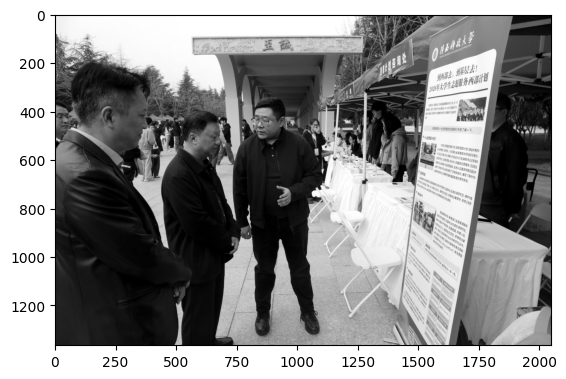

In [6]:
gray = 0.299*img[:,:,2] + 0.587*img[:,:,1] + 0.114*img[:,:,0]
plt.imshow(gray, cmap='gray')
plt.show()

Q2: 学生成绩计算

In [7]:
import numpy as np
scores = np.load("marks.npy")[:, 1:]
scores[:5]

array([[89, 79, 93, 87],
       [66, 56, 78, 84],
       [88, 57, 88, 84],
       [81, 61, 88, 87],
       [81, 70, 90, 83]])

In [8]:
w = [0.2, 0.3, 0.2, 0.3]
final = np.rint((scores * w).sum(1)).astype(int)  # scores @ w
final[:5]

array([86, 71, 78, 78, 80])

In [9]:
scores = np.hstack([scores, final.reshape(-1, 1)])
scores[:5]

array([[89, 79, 93, 87, 86],
       [66, 56, 78, 84, 71],
       [88, 57, 88, 84, 78],
       [81, 61, 88, 87, 78],
       [81, 70, 90, 83, 80]])

In [10]:
print(scores.max(0))
print(scores.min(0))
print(np.round(scores.mean(0), 2))
print(np.round(scores.std(0), 2))

[98 95 98 95 91]
[54 45 74 68 67]
[81.52 69.4  88.58 83.58 79.89]
[ 9.88 11.01  6.53  5.28  5.78]


In [11]:
print("90~100:", (scores >= 90).sum(0))
print("80~89 :", ((scores >= 80) & (scores < 90)).sum(0))
print("70~79 :", ((scores >= 70) & (scores < 80)).sum(0))
print("60~69 :", ((scores >= 60) & (scores < 70)).sum(0))
print("0~59  :", (scores < 60).sum(0))

90~100: [18  3 34  7  3]
80~89 : [25  8 21 44 32]
70~79 : [15 20 10 13 26]
60~69 : [ 5 21  0  1  4]
0~59  : [ 2 13  0  0  0]


Q3: 随机漫步，见课件ipynb

Q4: 绘制学生成绩

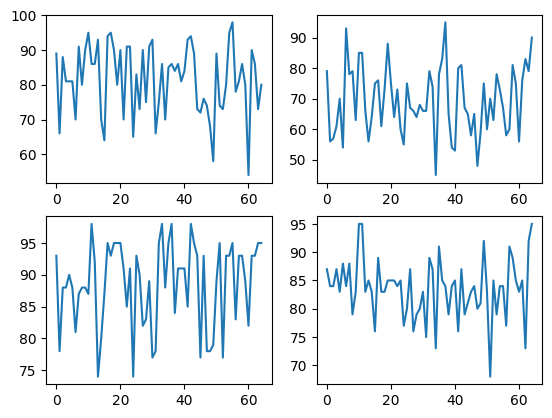

In [12]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2)
axes[0, 0].plot(scores[:, 0])
axes[0, 1].plot(scores[:, 1])
axes[1, 0].plot(scores[:, 2])
axes[1, 1].plot(scores[:, 3])
plt.show()

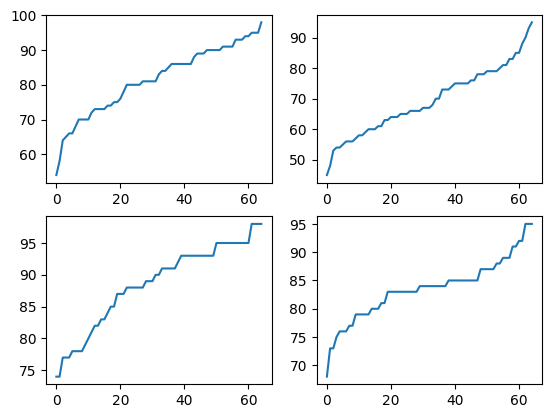

In [13]:
fig, axes = plt.subplots(2, 2)
axes[0, 0].plot(np.sort(scores[:, 0]))
axes[0, 1].plot(np.sort(scores[:, 1]))
axes[1, 0].plot(np.sort(scores[:, 2]))
axes[1, 1].plot(np.sort(scores[:, 3]))
plt.show()

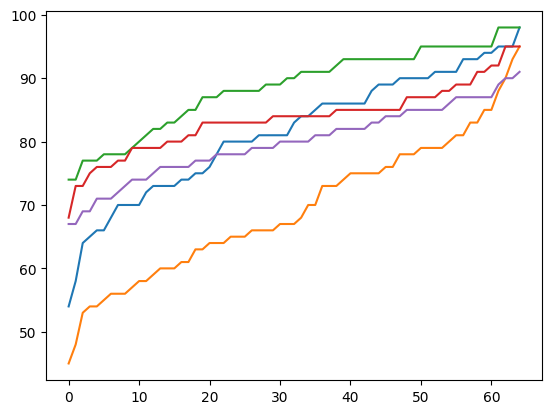

In [14]:
ax = plt.subplot()
ax.plot(np.sort(scores, 0))
plt.show()

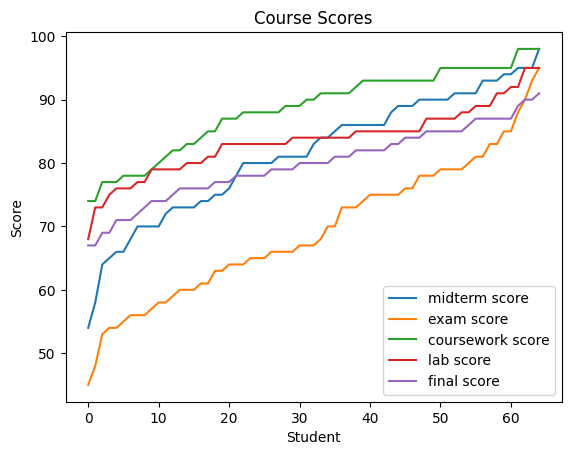

In [15]:
ax = plt.subplot()
ax.plot(np.sort(scores, 0))
plt.title('Course Scores')
plt.xlabel('Student')
plt.ylabel('Score')
plt.legend(['midterm score', 'exam score', 'coursework score', 'lab score', 'final score'])
plt.show()

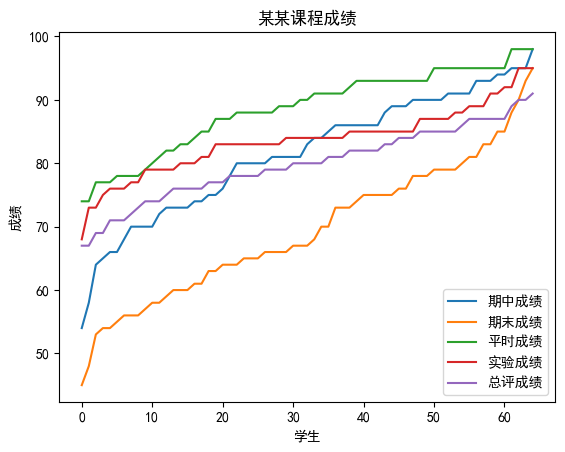

In [16]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False 

ax = plt.subplot()
ax.plot(np.sort(scores, 0), label=['期中成绩', '期末成绩', '平时成绩', '实验成绩', '总评成绩'])
plt.title('某某课程成绩')
plt.xlabel('学生')
plt.ylabel('成绩')
plt.legend(loc='lower right')
plt.show()

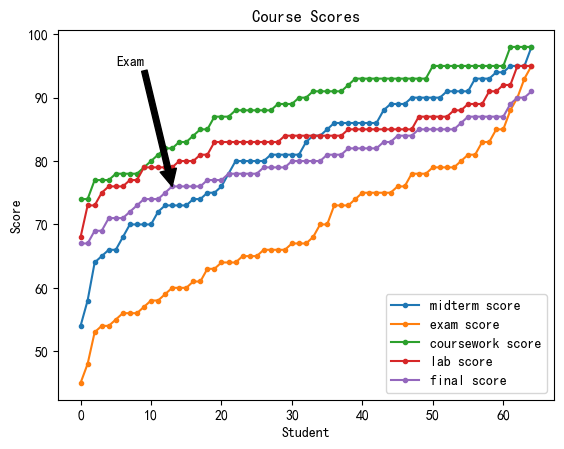

In [17]:
ax = plt.subplot()
ax.plot(np.sort(scores, 0), marker='.', label=['midterm score', 'exam score', 'coursework score', 'lab score', 'final score'])
plt.title('Course Scores')
plt.xlabel('Student')
plt.ylabel('Score')
plt.annotate('Exam', (13, 76), (5, 95), arrowprops=dict(facecolor='black'))
plt.legend(loc='lower right')
plt.show()

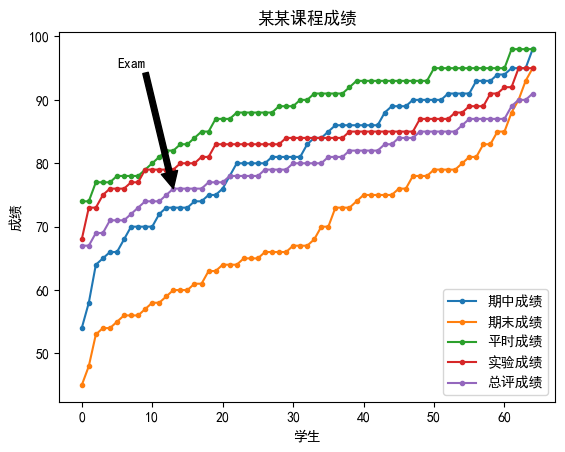

In [18]:
ax = plt.subplot()
ax.plot(np.sort(scores, 0), marker='.', label=['期中成绩', '期末成绩', '平时成绩', '实验成绩', '总评成绩'])
plt.title('某某课程成绩')
plt.xlabel('学生')
plt.ylabel('成绩')
plt.annotate('Exam', (13, 76), (5, 95), arrowprops=dict(facecolor='black'))
plt.legend(loc='lower right')
plt.show()

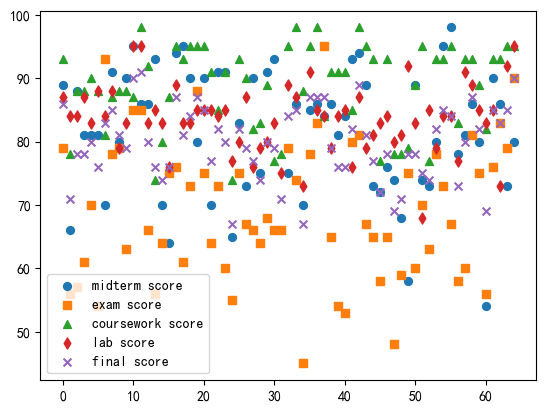

In [19]:
n, _ = scores.shape
ax = plt.subplot()
colors = plt.cm.tab10.colors
markers = ['o', 's', '^', 'd', 'x', '+', 'v', '*']
for i in range(5):
    ax.scatter(np.arange(n), scores[:, i], 32, color=colors[i], marker=markers[i])
plt.legend(['midterm score', 'exam score', 'coursework score', 'lab score', 'final score'])
plt.show()

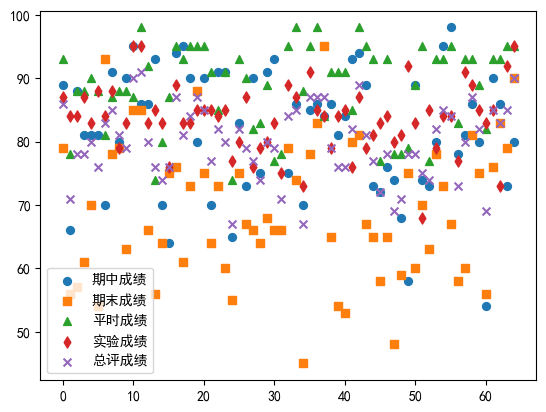

In [20]:
n, _ = scores.shape
ax = plt.subplot()
colors = plt.cm.tab10.colors
markers = ['o', 's', '^', 'd', 'x', '+', 'v', '*']
for i in range(5):
    ax.scatter(np.arange(n), scores[:, i], 32, color=colors[i], marker=markers[i])
plt.legend(['期中成绩', '期末成绩', '平时成绩', '实验成绩', '总评成绩'], loc='lower left')
plt.show()

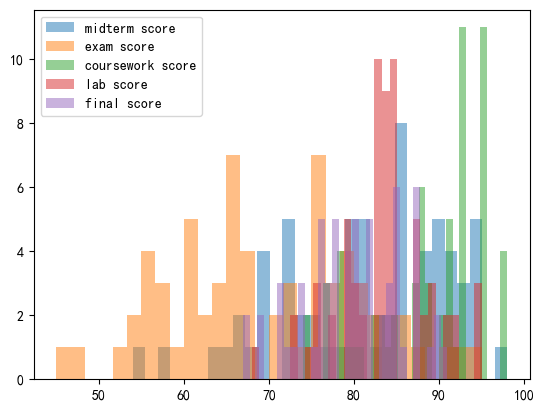

In [21]:
ax = plt.subplot()
for i in range(5):
    plt.hist(scores[:, i], bins=30, alpha=0.5)
plt.legend(['midterm score', 'exam score', 'coursework score', 'lab score', 'final score'])
plt.show()

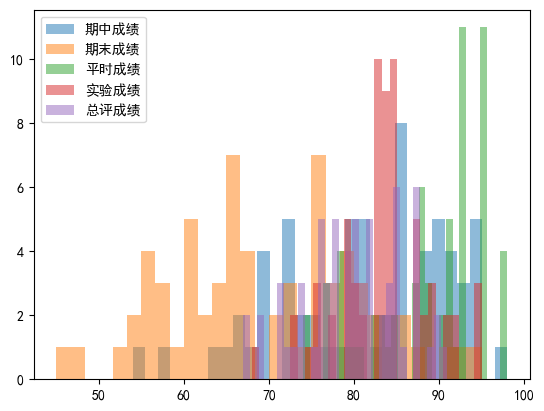

In [22]:
ax = plt.subplot()
for i in range(5):
    plt.hist(scores[:, i], bins=30, alpha=0.5)
plt.legend(['期中成绩', '期末成绩', '平时成绩', '实验成绩', '总评成绩'])
plt.show()

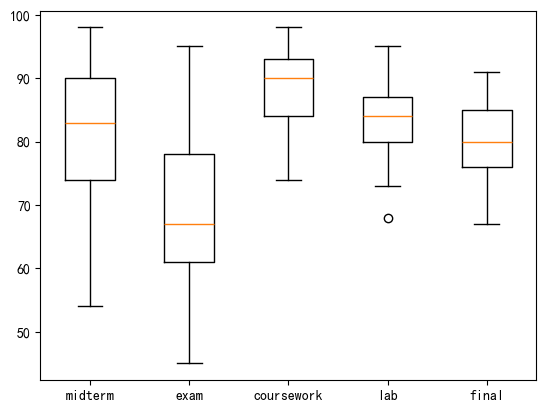

In [23]:
ax = plt.subplot()
ax.boxplot(scores)
ax.set_xticklabels(['midterm', 'exam', 'coursework', 'lab', 'final'])
plt.show()

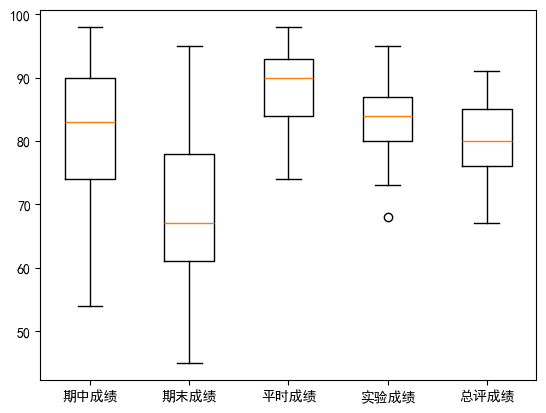

In [24]:
ax = plt.subplot()
ax.boxplot(scores)
ax.set_xticklabels(['期中成绩', '期末成绩', '平时成绩', '实验成绩', '总评成绩'])
plt.show()